# EJERCICIO PRACTICO CALIFORNIA HOUSING PRICES
![Logo](img/ITQ.png)
## Nombre: Gabriel Q. Pazmiño
### Fecha: 04/06/2026
<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **







# Práctica Académica
# Análisis de estructura, calidad y estadísticas descriptivas del dataset California Housing Prices

## Objetivo General

# Realizar un análisis exploratorio completo del dataset California Housing Prices mediante herramientas de Python, aplicando técnicas de inspección de datos, detección de valores nulos y estadística descriptiva, con el fin de comprender la estructura y calidad de los datos antes de aplicar modelos de aprendizaje automático.

## Objetivos Específicos
* Generar y cargar correctamente el archivo de datos desde una fuente externa (Kaggle)
* Visualizar y comprender la estructura inicial del dataset (primeros registros)
* Identificar tipos de datos, dimensiones y memoria utilizada
* Detectar valores nulos por columna para planificar su tratamiento
* Calcular y analizar estadísticas descriptivas (media, mediana, desviación estándar, rangos)
* Explorar la distribución de variables categóricas y numéricas

# Antecedentes / Fundamentación Teórica
### En el contexto del aprendizaje automático, antes de construir cualquier modelo predictivo es fundamental realizar un Análisis Exploratorio de Datos (EDA). Este proceso permite:

* Comprender la estructura del dataset: cuántas filas y columnas tenemos
* Identificar problemas de calidad: valores nulos, datos atípicos, inconsistencias
* Conocer la distribución de cada variable mediante estadísticos descriptivos
* Detectar escalas y rangos para futuras transformaciones

### Las técnicas de EDA son el primer paso indispensable en cualquier proyecto de ciencia de datos y sientan las bases para:
* Limpieza de datos
* Ingeniería de características
* Selección de algoritmos apropiados
* Normalización o estandarización posterior

# Escenario de Práctica
## Una inmobiliaria especializada en el mercado californiano desea desarrollar un modelo predictivo para estimar el valor medio de las viviendas por distrito. Sin embargo, antes de implementar algoritmos de machine learning, el equipo de datos necesita realizar un análisis exploratorio completo para:

* Verificar la integridad de los datos recopilados del censo de 1990
* Identificar qué columnas presentan valores faltantes
* Comprender la distribución estadística de cada variable
* Detectar posibles problemas de calidad que afectarían al modelo
* Se solicita al analista generar un reporte con la exploración inicial del dataset.

# Conjunto de Datos a Utilizar
## Dataset: California Housing Prices (camnugent/california-housing-prices)

### Descripción: Información del censo de California de 1990 con 10 variables

# INSTALACIÓN DE LIBRERÍA KAGGLEHUB
# La librería kagglehub nos permite descargar datasets directamente desde Kaggle

# Ejecutar el siguiente comando en la terminal:
# pip install kagglehub


In [2]:
#Importacion de librerias 
import pandas as pd
import numpy as np
import kagglehub
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler

import zipfile

C:\Users\NW\anaconda3\envs\cuadernoIA2026\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
#Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR']="C:/Users/NW/OneDrive/Escritorio/DBRS/INTELIGENCIA ARTIFICIAL/FUNDAMENTOS DE MACHINE LEARNING/cuadernoIA2026/.kaggle"

In [7]:
#Creamos la carpeta dataset
os.makedirs("dataset", exist_ok=True)

In [8]:
#Descargamos el dataset
!kaggle datasets download -d camnugent/california-housing-prices


Dataset URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices
License(s): CC0-1.0




  0%|          | 0.00/400k [00:00<?, ?B/s]
100%|##########| 400k/400k [00:00<00:00, 1.37MB/s]
100%|##########| 400k/400k [00:00<00:00, 1.37MB/s]


In [9]:
#Descompriminos el archivo 
with zipfile.ZipFile("california-housing-prices.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [12]:
#Cargamos el conjunto de datos
df = pd.read_csv("dataset/housing.csv")

In [13]:
#mostramos el conjunto de datos"
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [14]:
#Mostramos los detalles de nuesto dataset
df.info()
#Vrificamos si tenemos datos nulos si lo tenemos lo sumamos 
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [15]:
# TRATAMIENTO DE VALORES NULOS
# Como vemos en el resultado anterior, la columna 'total_bedrooms' tiene 207 valores nulos
# Vamos a remplazar estos valores nulos con la mediana de la columna
# La mediana es más robusta que la media para valores atípicos

# Calculamos la mediana de total_bedrooms
mediana_bedrooms = df['total_bedrooms'].median()
print(f"La mediana de total_bedrooms es: {mediana_bedrooms}")

# Rellenamos los valores nulos con la mediana
df['total_bedrooms'] = df['total_bedrooms'].fillna(mediana_bedrooms)

# Verificamos que ya no hay valores nulos
print("\nVerificación de valores nulos después del tratamiento:")
print(df.isnull().sum())

La mediana de total_bedrooms es: 435.0

Verificación de valores nulos después del tratamiento:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [16]:
# ESTADÍSTICA DESCRIPTIVA DEL DATAFRAME
# Mostramos las medidas estadísticas principales de nuestras variables numéricas
print("\nESTADISTICA DESCRIPTIVA DEL DATAFRAME")
df.describe()


ESTADISTICA DESCRIPTIVA DEL DATAFRAME


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [17]:
# MEDIDAS ESTADÍSTICAS ADICIONALES
# Calculamos medidas adicionales para entender mejor nuestros datos

# MEDIANA - Valor central de los datos
print("="*50)
print("MEDIANA DE CADA VARIABLE")
print("="*50)
print(df.median(numeric_only=True))

# VARIANZA - Mide la dispersión de los datos
print("\n" + "="*50)
print("VARIANZA DE CADA VARIABLE")
print("="*50)
print(df.var(numeric_only=True))

# DESVIACIÓN ESTÁNDAR - Raíz cuadrada de la varianza
print("\n" + "="*50)
print("DESVIACIÓN ESTÁNDAR DE CADA VARIABLE")
print("="*50)
print(df.std(numeric_only=True))

MEDIANA DE CADA VARIABLE
longitude               -118.4900
latitude                  34.2600
housing_median_age        29.0000
total_rooms             2127.0000
total_bedrooms           435.0000
population              1166.0000
households               409.0000
median_income              3.5348
median_house_value    179700.0000
dtype: float64

VARIANZA DE CADA VARIABLE
longitude             4.014139e+00
latitude              4.562293e+00
housing_median_age    1.583963e+02
total_rooms           4.759445e+06
total_bedrooms        1.758895e+05
population            1.282470e+06
households            1.461760e+05
median_income         3.609323e+00
median_house_value    1.331615e+10
dtype: float64

DESVIACIÓN ESTÁNDAR DE CADA VARIABLE
longitude                  2.003532
latitude                   2.135952
housing_median_age        12.585558
total_rooms             2181.615252
total_bedrooms           419.391878
population              1132.462122
households               382.329753
median_

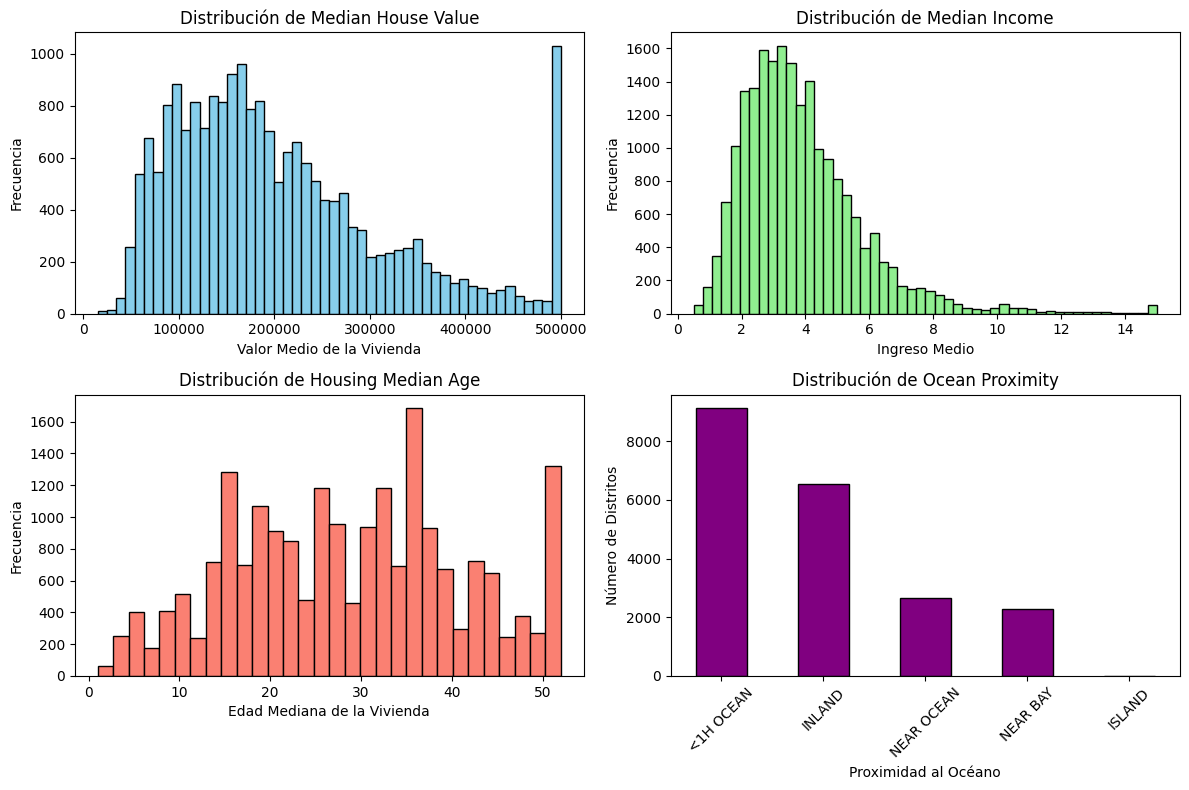

In [18]:
# VISUALIZACIÓN DE DATOS
# Generamos gráficos para visualizar la distribución de nuestros datos
# Configuramos el estilo de los gráficos

# Configuramos el tamaño de las figuras
plt.figure(figsize=(12, 8))

# Histograma de la variable objetivo 'median_house_value'
plt.subplot(2, 2, 1)
plt.hist(df['median_house_value'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Valor Medio de la Vivienda')
plt.ylabel('Frecuencia')
plt.title('Distribución de Median House Value')

# Histograma de 'median_income'
plt.subplot(2, 2, 2)
plt.hist(df['median_income'], bins=50, color='lightgreen', edgecolor='black')
plt.xlabel('Ingreso Medio')
plt.ylabel('Frecuencia')
plt.title('Distribución de Median Income')

# Histograma de 'housing_median_age'
plt.subplot(2, 2, 3)
plt.hist(df['housing_median_age'], bins=30, color='salmon', edgecolor='black')
plt.xlabel('Edad Mediana de la Vivienda')
plt.ylabel('Frecuencia')
plt.title('Distribución de Housing Median Age')

# Gráfico de barras para ocean_proximity
plt.subplot(2, 2, 4)
df['ocean_proximity'].value_counts().plot(kind='bar', color='purple', edgecolor='black')
plt.xlabel('Proximidad al Océano')
plt.ylabel('Número de Distritos')
plt.title('Distribución de Ocean Proximity')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS)
# Usamos el método del Rango Intercuartil (IQR) para detectar outliers
# Outliers son valores que se alejan significativamente del resto de los datos

print("="*50)
print("DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS)")
print("="*50)

# Seleccionamos solo las variables numéricas
variables_numericas = df.select_dtypes(include=[np.number]).columns

for variable in variables_numericas:
    # Calculamos Q1 (primer cuartil) y Q3 (tercer cuartil)
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1
    
    # Definimos límites para outliers
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contamos outliers
    outliers = df[(df[variable] < limite_inferior) | (df[variable] > limite_superior)].shape[0]
    porcentaje_outliers = (outliers / df.shape[0]) * 100
    
    print(f"{variable:<20} → {outliers:5} outliers ({porcentaje_outliers:.2f}%)")

DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS)
longitude            →     0 outliers (0.00%)
latitude             →     0 outliers (0.00%)
housing_median_age   →     0 outliers (0.00%)
total_rooms          →  1287 outliers (6.24%)
total_bedrooms       →  1306 outliers (6.33%)
population           →  1196 outliers (5.79%)
households           →  1220 outliers (5.91%)
median_income        →   681 outliers (3.30%)
median_house_value   →  1071 outliers (5.19%)


In [21]:
# PRIMERO: Calcular la matriz de correlación (esto va ANTES del resumen)
correlacion = df.corr(numeric_only=True)

# RESUMEN FINAL DEL ANÁLISIS
# Mostramos un resumen con los hallazgos más importantes

print("="*50)
print("RESUMEN FINAL DEL ANÁLISIS EXPLORATORIO")
print("="*50)

print("\n📊 DATOS GENERALES:")
print(f"   • Total de registros: {df.shape[0]}")
print(f"   • Total de variables: {df.shape[1]}")
# CORREGIDO: incluir 'str' para evitar el warning
print(f"   • Variables numéricas: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"   • Variables categóricas: {len(df.select_dtypes(include=['object', 'str', 'category']).columns)}")

print("\n📊 CALIDAD DE LOS DATOS:")
print(f"   • Valores nulos después del tratamiento: {df.isnull().sum().sum()}")
print(f"   • Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n📊 VARIABLE OBJETIVO (median_house_value):")
print(f"   • Valor mínimo: ${df['median_house_value'].min():,.0f}")
print(f"   • Valor máximo: ${df['median_house_value'].max():,.0f}")
print(f"   • Media: ${df['median_house_value'].mean():,.0f}")
print(f"   • Mediana: ${df['median_house_value'].median():,.0f}")

# CORREGIDO: Ahora 'correlacion' sí está definida
print("\n📊 VARIABLES CON MAYOR CORRELACIÓN (positiva) con el valor de la vivienda:")
correlaciones_positivas = correlacion['median_house_value'].sort_values(ascending=False)
for var in correlaciones_positivas.index[1:4]:  # Top 3 después de la variable misma
    print(f"   • {var}: {correlaciones_positivas[var]:.3f}")

# EXTRA: También muestra las correlaciones negativas (útil)
print("\n📊 VARIABLES CON MAYOR CORRELACIÓN (negativa) con el valor de la vivienda:")
correlaciones_negativas = correlacion['median_house_value'].sort_values(ascending=True)
for var in correlaciones_negativas.index[:3]:  # Top 3 negativas
    print(f"   • {var}: {correlaciones_negativas[var]:.3f}")

print("\n📊 VARIABLE CATEGÓRICA (ocean_proximity):")
# Verificar si la columna existe antes de usarla
if 'ocean_proximity' in df.columns:
    categoria_mas_comun = df['ocean_proximity'].value_counts().index[0]
    categoria_menos_comun = df['ocean_proximity'].value_counts().index[-1]
    print(f"   • Categorías únicas: {df['ocean_proximity'].nunique()}")
    print(f"   • Categoría más común: {categoria_mas_comun} ({df['ocean_proximity'].value_counts().iloc[0]:,} registros)")
    print(f"   • Categoría menos común: {categoria_menos_comun} ({df['ocean_proximity'].value_counts().iloc[-1]:,} registros)")
    
    # Bonus: valor promedio por categoría
    print("\n   Valor promedio de vivienda por categoría:")
    promedio_categoria = df.groupby('ocean_proximity')['median_house_value'].mean().sort_values(ascending=False)
    for cat, valor in promedio_categoria.head(3).items():
        print(f"      • {cat}: ${valor:,.0f}")
else:
    print("   • Nota: 'ocean_proximity' no está en el dataset (usando dataset de sklearn)")

print("\n" + "="*50)
print("✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("="*50)

RESUMEN FINAL DEL ANÁLISIS EXPLORATORIO

📊 DATOS GENERALES:
   • Total de registros: 20640
   • Total de variables: 10
   • Variables numéricas: 9
   • Variables categóricas: 1

📊 CALIDAD DE LOS DATOS:
   • Valores nulos después del tratamiento: 0
   • Memoria utilizada: 2.54 MB

📊 VARIABLE OBJETIVO (median_house_value):
   • Valor mínimo: $14,999
   • Valor máximo: $500,001
   • Media: $206,856
   • Mediana: $179,700

📊 VARIABLES CON MAYOR CORRELACIÓN (positiva) con el valor de la vivienda:
   • median_income: 0.688
   • total_rooms: 0.134
   • housing_median_age: 0.106

📊 VARIABLES CON MAYOR CORRELACIÓN (negativa) con el valor de la vivienda:
   • latitude: -0.144
   • longitude: -0.046
   • population: -0.025

📊 VARIABLE CATEGÓRICA (ocean_proximity):
   • Categorías únicas: 5
   • Categoría más común: <1H OCEAN (9,136 registros)
   • Categoría menos común: ISLAND (5 registros)

   Valor promedio de vivienda por categoría:
      • ISLAND: $380,440
      • NEAR BAY: $259,212
      • N

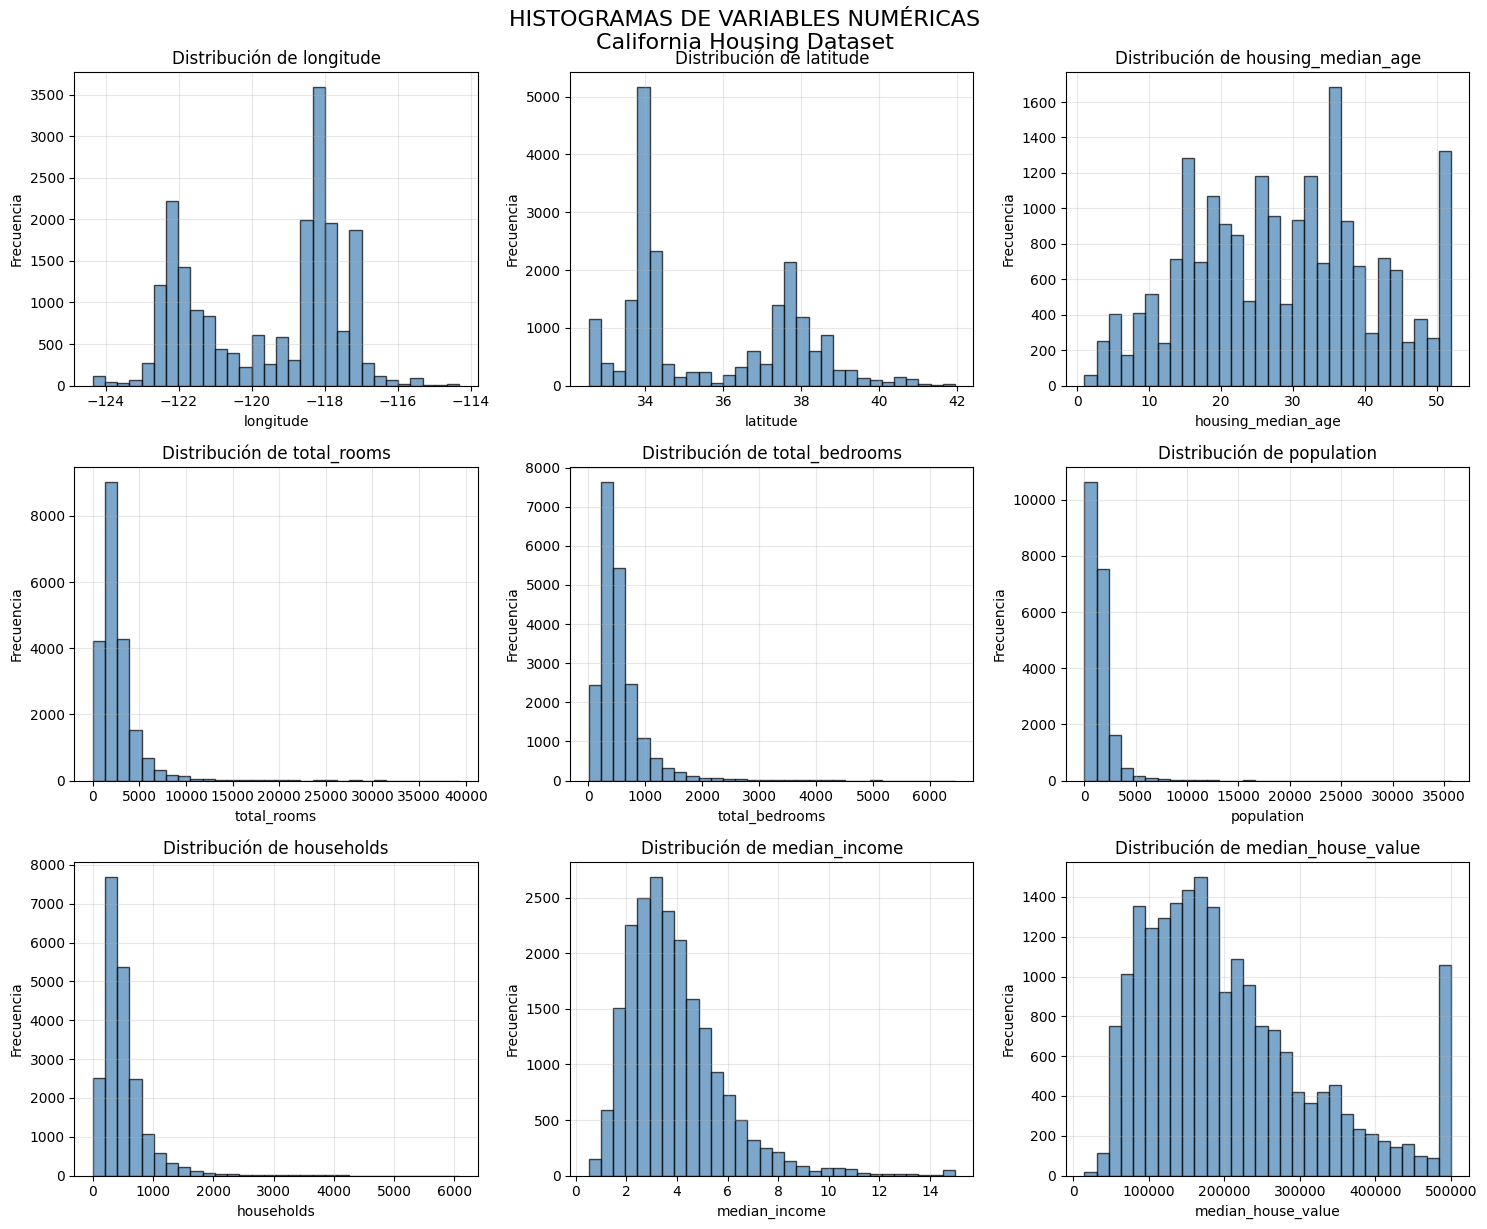

In [22]:
# DISTRIBUCIÓN DE VARIABLES NUMÉRICAS MEDIANTE HISTOGRAMAS
# Los histogramas nos permiten visualizar cómo se distribuyen los datos
# En el eje X tenemos los valores de la variable
# En el eje Y tenemos la frecuencia (cuántas veces aparece cada valor)

# Configuramos el tamaño de la figura general
plt.figure(figsize=(15, 12))

# Seleccionamos solo las columnas numéricas
variables_numericas = df.select_dtypes(include=[np.number]).columns

# Creamos un histograma para cada variable numérica
for i, variable in enumerate(variables_numericas, 1):
    plt.subplot(3, 3, i)  # 3 filas, 3 columnas (tenemos 9 variables numéricas)
    plt.hist(df[variable], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    plt.xlabel(variable, fontsize=10)
    plt.ylabel('Frecuencia', fontsize=10)
    plt.title(f'Distribución de {variable}', fontsize=12)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('HISTOGRAMAS DE VARIABLES NUMÉRICAS\nCalifornia Housing Dataset', 
             fontsize=16, y=1.02)
plt.show()

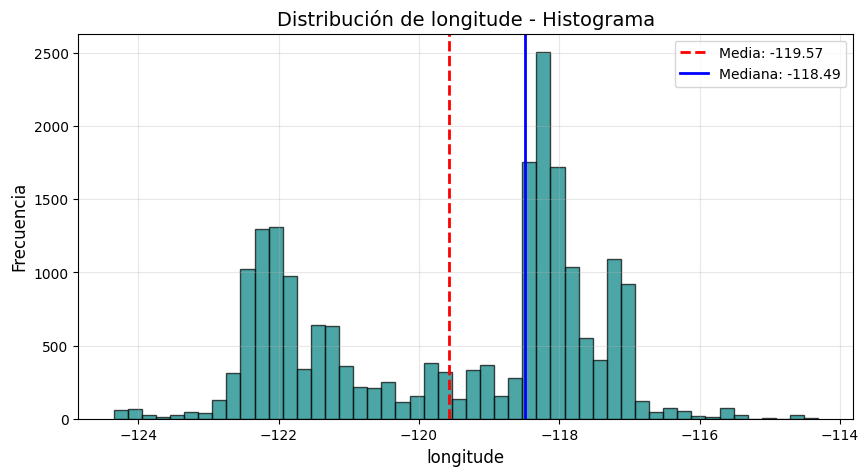


Estadísticas de longitude:
  • Media: -119.5697
  • Mediana: -118.4900
  • Desviación estándar: 2.0035
  • Mínimo: -124.3500
  • Máximo: -114.3100
  • Asimetría (skewness): -0.2978
--------------------------------------------------


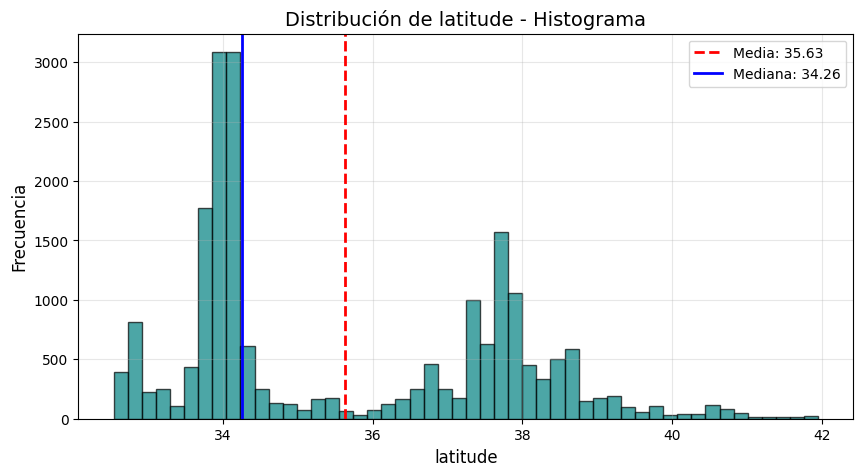


Estadísticas de latitude:
  • Media: 35.6319
  • Mediana: 34.2600
  • Desviación estándar: 2.1360
  • Mínimo: 32.5400
  • Máximo: 41.9500
  • Asimetría (skewness): 0.4660
--------------------------------------------------


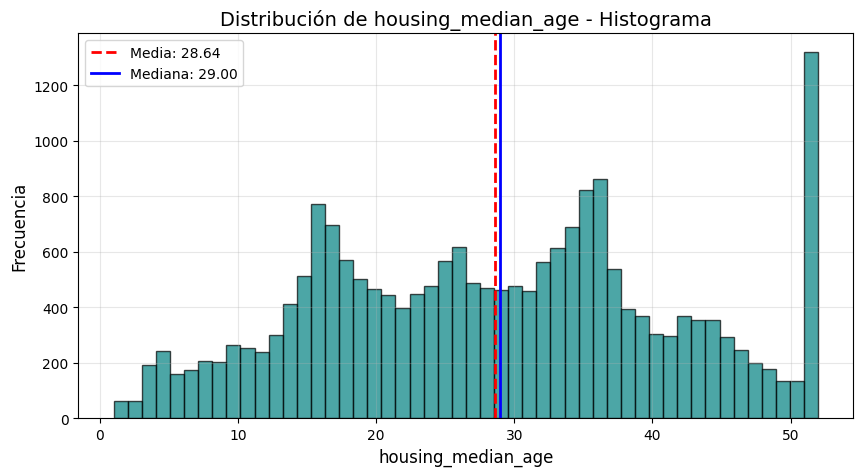


Estadísticas de housing_median_age:
  • Media: 28.6395
  • Mediana: 29.0000
  • Desviación estándar: 12.5856
  • Mínimo: 1.0000
  • Máximo: 52.0000
  • Asimetría (skewness): 0.0603
--------------------------------------------------


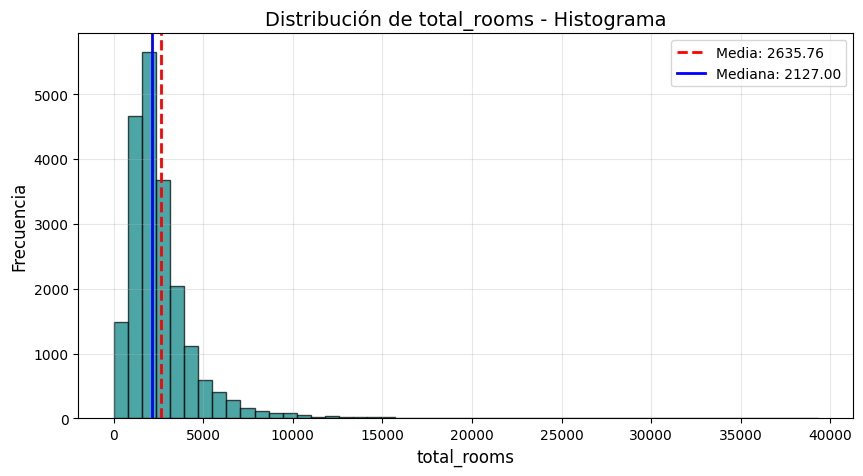


Estadísticas de total_rooms:
  • Media: 2635.7631
  • Mediana: 2127.0000
  • Desviación estándar: 2181.6153
  • Mínimo: 2.0000
  • Máximo: 39320.0000
  • Asimetría (skewness): 4.1473
--------------------------------------------------


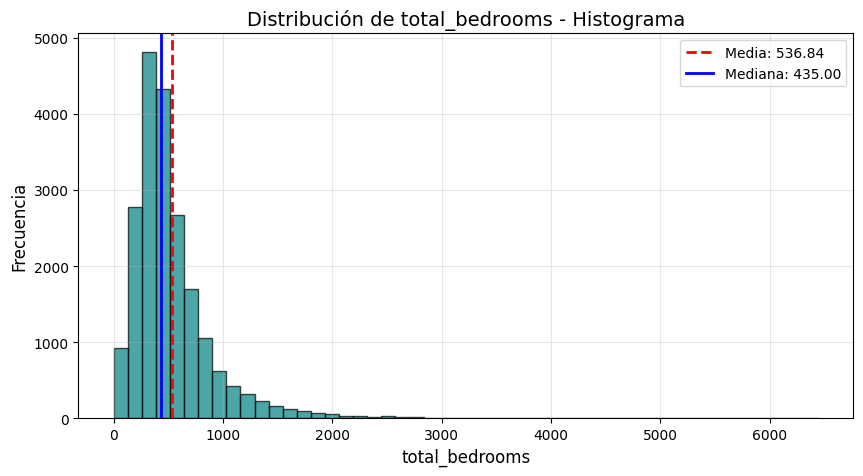


Estadísticas de total_bedrooms:
  • Media: 536.8389
  • Mediana: 435.0000
  • Desviación estándar: 419.3919
  • Mínimo: 1.0000
  • Máximo: 6445.0000
  • Asimetría (skewness): 3.4811
--------------------------------------------------


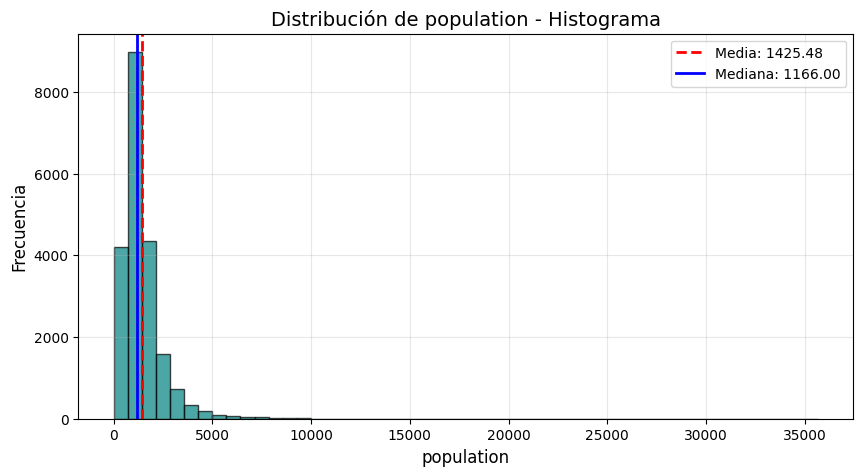


Estadísticas de population:
  • Media: 1425.4767
  • Mediana: 1166.0000
  • Desviación estándar: 1132.4621
  • Mínimo: 3.0000
  • Máximo: 35682.0000
  • Asimetría (skewness): 4.9359
--------------------------------------------------


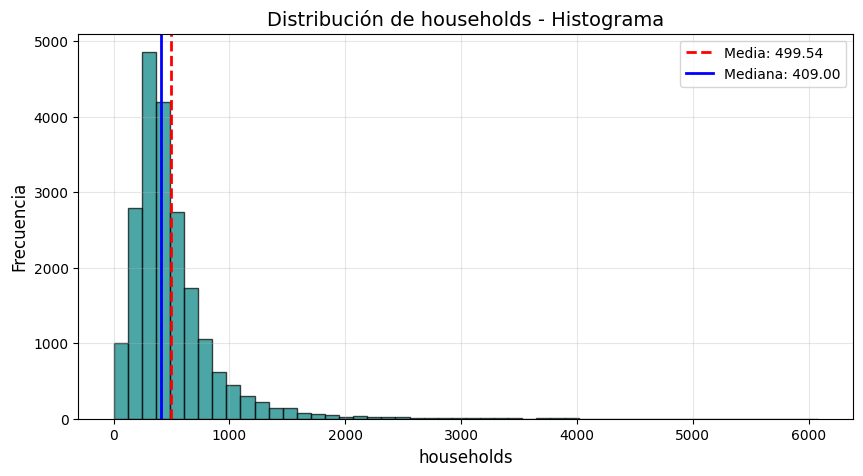


Estadísticas de households:
  • Media: 499.5397
  • Mediana: 409.0000
  • Desviación estándar: 382.3298
  • Mínimo: 1.0000
  • Máximo: 6082.0000
  • Asimetría (skewness): 3.4104
--------------------------------------------------


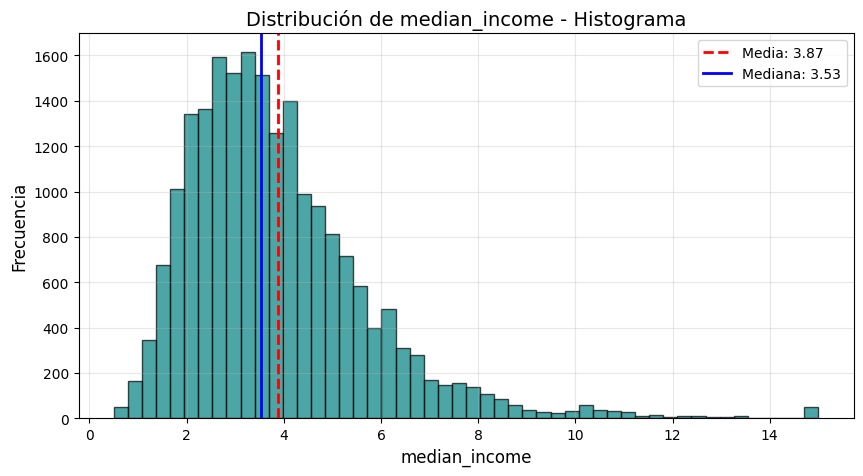


Estadísticas de median_income:
  • Media: 3.8707
  • Mediana: 3.5348
  • Desviación estándar: 1.8998
  • Mínimo: 0.4999
  • Máximo: 15.0001
  • Asimetría (skewness): 1.6467
--------------------------------------------------


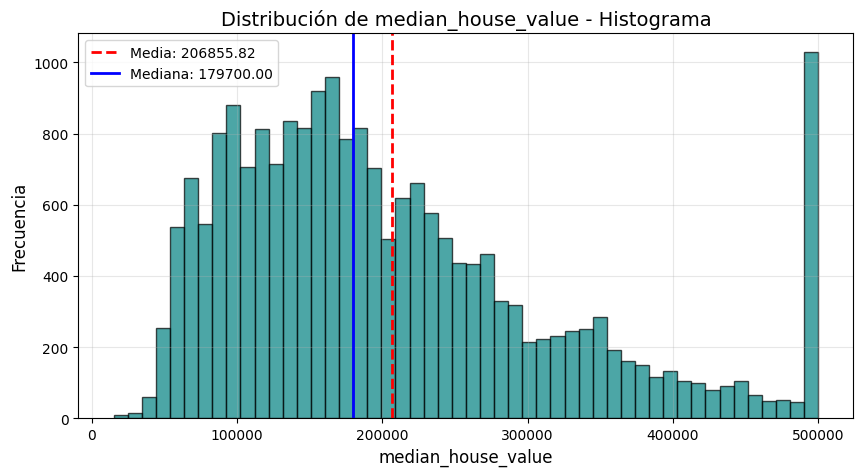


Estadísticas de median_house_value:
  • Media: 206855.8169
  • Mediana: 179700.0000
  • Desviación estándar: 115395.6159
  • Mínimo: 14999.0000
  • Máximo: 500001.0000
  • Asimetría (skewness): 0.9778
--------------------------------------------------


In [23]:
# HISTOGRAMAS INDIVIDUALES CON MÁS DETALLE
# Visualizamos cada variable numérica por separado con mayor detalle
# Esto nos permite identificar asimetrías, valores atípicos y patrones

variables_numericas = df.select_dtypes(include=[np.number]).columns

for variable in variables_numericas:
    plt.figure(figsize=(10, 5))
    
    # Histograma principal
    plt.hist(df[variable], bins=50, color='teal', edgecolor='black', alpha=0.7)
    
    # Línea vertical para la media
    media = df[variable].mean()
    plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
    
    # Línea vertical para la mediana
    mediana = df[variable].median()
    plt.axvline(mediana, color='blue', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
    
    plt.xlabel(variable, fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.title(f'Distribución de {variable} - Histograma', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Mostramos estadísticas clave de la variable
    print(f"\nEstadísticas de {variable}:")
    print(f"  • Media: {media:.4f}")
    print(f"  • Mediana: {mediana:.4f}")
    print(f"  • Desviación estándar: {df[variable].std():.4f}")
    print(f"  • Mínimo: {df[variable].min():.4f}")
    print(f"  • Máximo: {df[variable].max():.4f}")
    print(f"  • Asimetría (skewness): {df[variable].skew():.4f}")
    print("-" * 50)

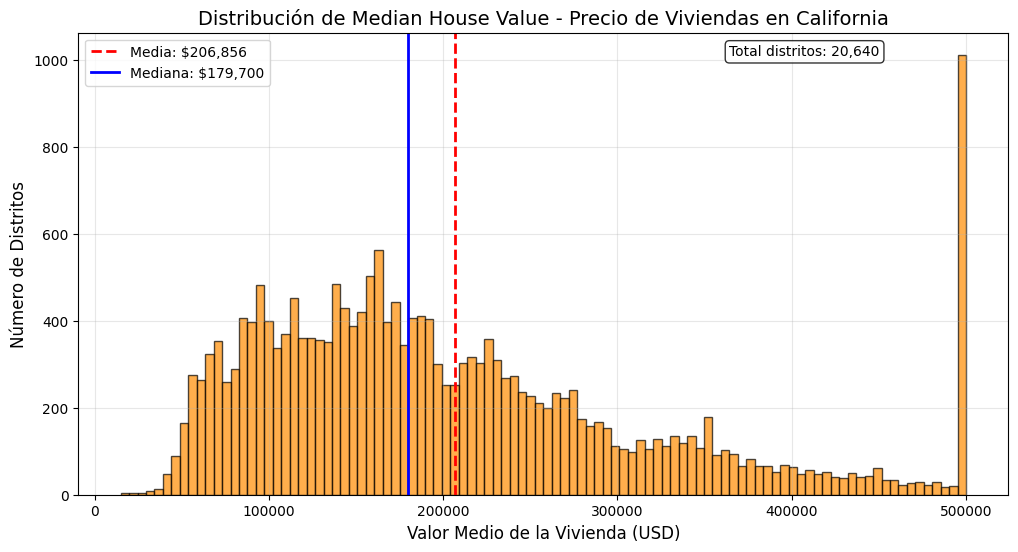


📊 ANÁLISIS DE LA DISTRIBUCIÓN DE median_house_value:
⚠️ La media es mayor que la mediana → Distribución con asimetría POSITIVA
   (Hay distritos con valores muy altos que jalan la media hacia arriba)

📌 Interpretación:
   • La mayoría de los distritos tienen valores entre $119,600 y $264,725
   • El 50% de los distritos tienen un valor menor a $179,700
   • Existen distritos con valores extremadamente altos (hasta $500,001)


In [24]:
# HISTOGRAMA DE LA VARIABLE OBJETIVO (median_house_value)
# La variable objetivo es la que queremos predecir
# Es importante entender su distribución

plt.figure(figsize=(12, 6))

# Histograma con más bins para mayor detalle
plt.hist(df['median_house_value'], bins=100, color='darkorange', edgecolor='black', alpha=0.7)

# Líneas de media y mediana
media = df['median_house_value'].mean()
mediana = df['median_house_value'].median()
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: ${media:,.0f}')
plt.axvline(mediana, color='blue', linestyle='-', linewidth=2, label=f'Mediana: ${mediana:,.0f}')

plt.xlabel('Valor Medio de la Vivienda (USD)', fontsize=12)
plt.ylabel('Número de Distritos', fontsize=12)
plt.title('Distribución de Median House Value - Precio de Viviendas en California', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Agregamos texto con información adicional
plt.text(0.7, 0.95, f'Total distritos: {len(df):,}', 
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.show()

# Análisis de la distribución
print("\n📊 ANÁLISIS DE LA DISTRIBUCIÓN DE median_house_value:")
print("="*50)
if media > mediana:
    print("⚠️ La media es mayor que la mediana → Distribución con asimetría POSITIVA")
    print("   (Hay distritos con valores muy altos que jalan la media hacia arriba)")
elif media < mediana:
    print("⚠️ La media es menor que la mediana → Distribución con asimetría NEGATIVA")
else:
    print("✅ La media es igual a la mediana → Distribución SIMÉTRICA")

print(f"\n📌 Interpretación:")
print(f"   • La mayoría de los distritos tienen valores entre ${df['median_house_value'].quantile(0.25):,.0f} y ${df['median_house_value'].quantile(0.75):,.0f}")
print(f"   • El 50% de los distritos tienen un valor menor a ${mediana:,.0f}")
print(f"   • Existen distritos con valores extremadamente altos (hasta ${df['median_house_value'].max():,.0f})")

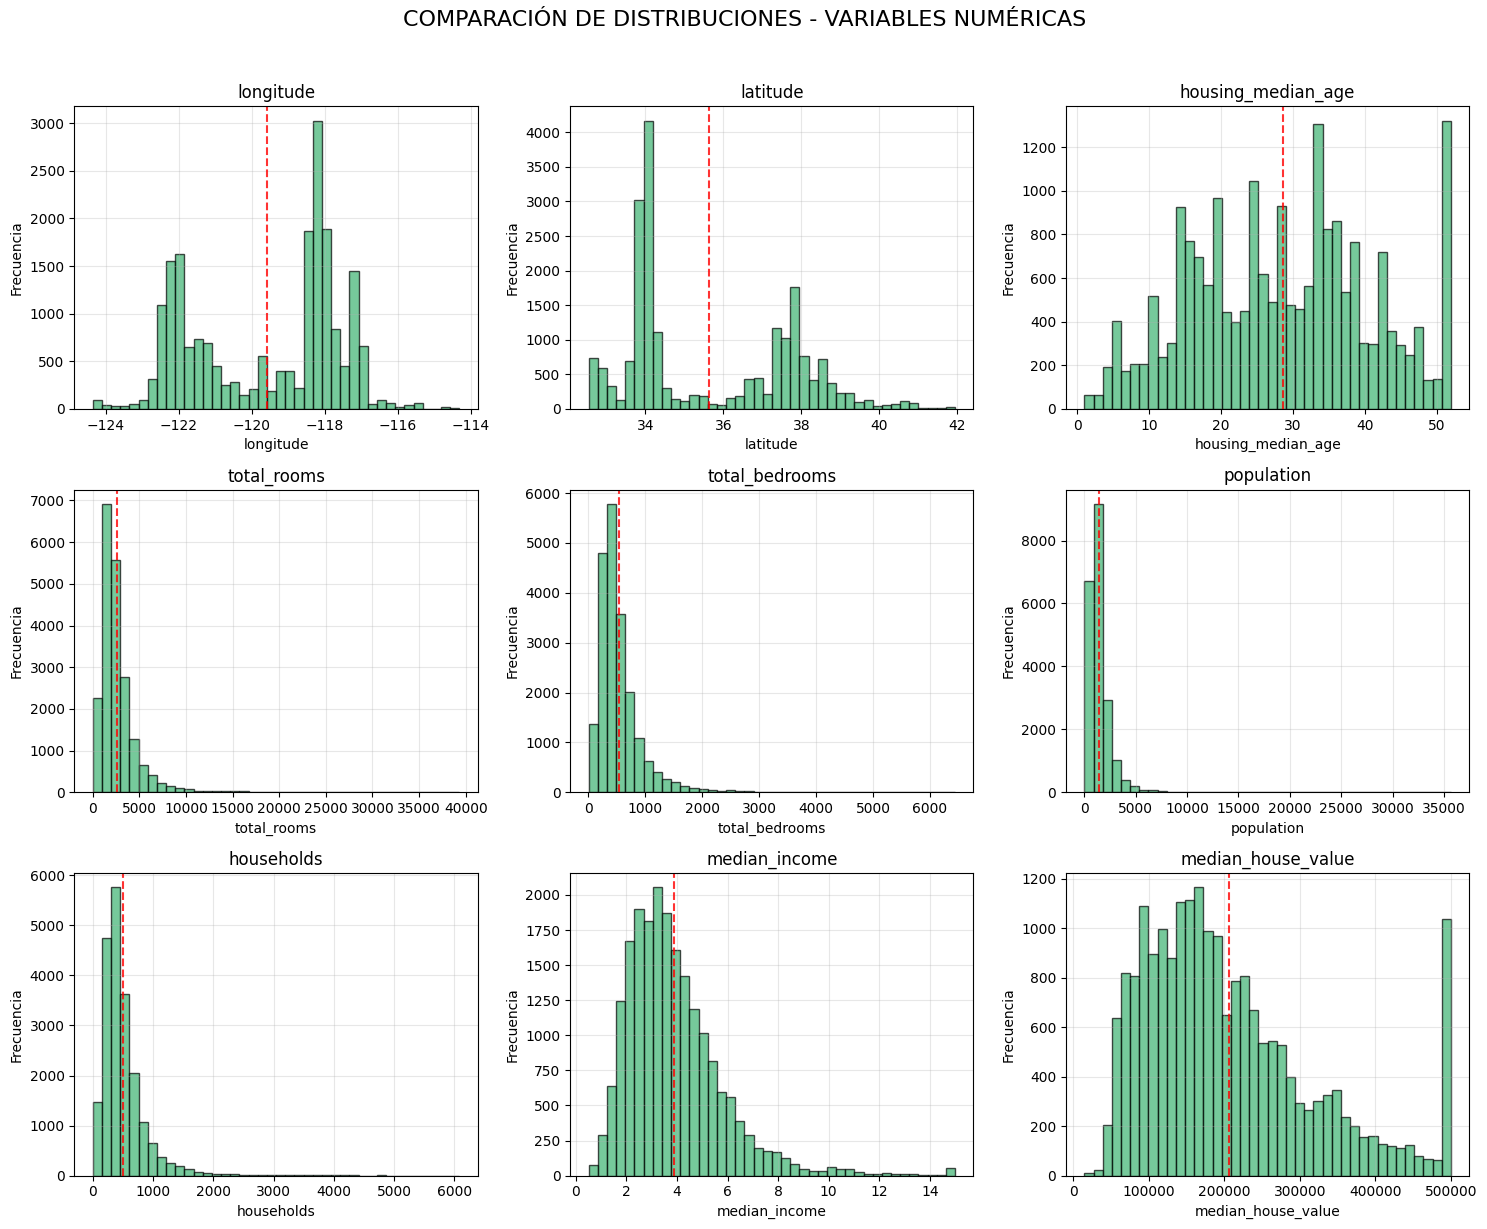

In [25]:
# COMPARACIÓN DE DISTRIBUCIONES
# Usamos subplots para comparar todas las distribuciones en una sola vista
# Esto nos permite identificar visualmente qué variables tienen distribuciones similares

# Configuramos la figura
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()  # Aplanamos el arreglo de ejes

# Creamos histogramas para cada variable numérica
for idx, variable in enumerate(variables_numericas):
    axes[idx].hist(df[variable], bins=40, color='mediumseagreen', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(variable, fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].set_title(f'{variable}', fontsize=12)
    axes[idx].grid(True, alpha=0.3)
    
    # Agregamos línea de media
    media_val = df[variable].mean()
    axes[idx].axvline(media_val, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

# Ocultamos el último subplot si no lo necesitamos (si hay menos de 9 variables)
if len(variables_numericas) < 9:
    for idx in range(len(variables_numericas), 9):
        axes[idx].set_visible(False)

plt.suptitle('COMPARACIÓN DE DISTRIBUCIONES - VARIABLES NUMÉRICAS', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

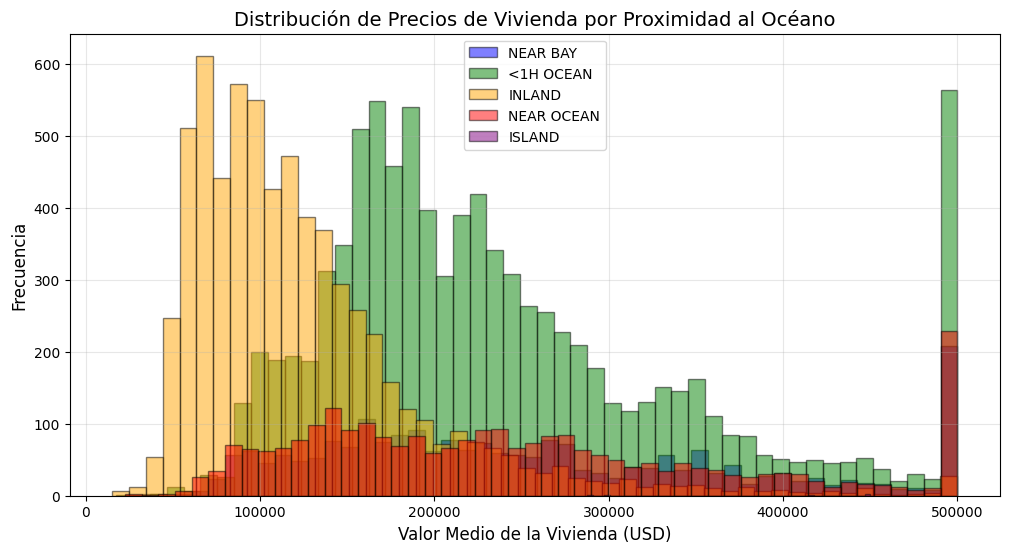


📊 ESTADÍSTICAS DE median_house_value POR CATEGORÍA:
Categoría                   Media      Mediana          Std   Conteo
------------------------------------------------------------
NEAR BAY             $   259,212 $   233,800 $   122,819     2290
<1H OCEAN            $   240,084 $   214,850 $   106,124     9136
INLAND               $   124,805 $   108,500 $    70,008     6551
NEAR OCEAN           $   249,434 $   229,450 $   122,477     2658
ISLAND               $   380,440 $   414,700 $    80,560        5


In [26]:
# ANÁLISIS DE DISTRIBUCIÓN POR CATEGORÍA (OCEAN_PROXIMITY)
# Comparamos cómo se distribuye el valor de las viviendas según la proximidad al océano
# Esto nos ayuda a entender si la ubicación afecta el precio

plt.figure(figsize=(12, 6))

# Creamos un histograma para cada categoría de ocean_proximity
categorias = df['ocean_proximity'].unique()
colores = ['blue', 'green', 'orange', 'red', 'purple']

for categoria, color in zip(categorias, colores):
    datos_categoria = df[df['ocean_proximity'] == categoria]['median_house_value']
    plt.hist(datos_categoria, bins=50, alpha=0.5, label=categoria, color=color, edgecolor='black')

plt.xlabel('Valor Medio de la Vivienda (USD)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Precios de Vivienda por Proximidad al Océano', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Mostramos estadísticas por categoría
print("\n📊 ESTADÍSTICAS DE median_house_value POR CATEGORÍA:")
print("="*60)
print(f"{'Categoría':<20} {'Media':>12} {'Mediana':>12} {'Std':>12} {'Conteo':>8}")
print("-"*60)

for categoria in categorias:
    datos = df[df['ocean_proximity'] == categoria]['median_house_value']
    print(f"{categoria:<20} ${datos.mean():>10,.0f} ${datos.median():>10,.0f} ${datos.std():>10,.0f} {len(datos):>8}")

In [27]:
# IDENTIFICACIÓN DE DATOS A LIMPIAR

# Primero verificamos qué problemas tiene nuestro dataset
print("="*50)
print("DIAGNÓSTICO DE CALIDAD DE DATOS")
print("="*50)

# 1. Verificamos valores nulos
print("\n📊 VALORES NULOS:")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

# 2. Verificamos tipos de datos incorrectos
print("\n📊 TIPOS DE DATOS:")
print(df.dtypes)

# 3. Verificamos valores duplicados
print(f"\n📊 REGISTROS DUPLICADOS: {df.duplicated().sum()}")

# 4. Verificamos valores atípicos (outliers)
print("\n📊 VALORES ATÍPICOS (outliers) - Resumen estadístico:")
print(df.describe())

DIAGNÓSTICO DE CALIDAD DE DATOS

📊 VALORES NULOS:
Series([], dtype: int64)

📊 TIPOS DE DATOS:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

📊 REGISTROS DUPLICADOS: 0

📊 VALORES ATÍPICOS (outliers) - Resumen estadístico:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.0

In [28]:
# LIMPIEZA 1: VALORES NULOS EN total_bedrooms

print("="*50)
print("TRATAMIENTO DE VALORES NULOS")
print("="*50)

# Verificamos cuántos nulos hay
print(f"Valores nulos en total_bedrooms: {df['total_bedrooms'].isnull().sum()}")

# OPCIÓN 1: Rellenar con la MEDIANA (recomendado para esta variable)
# La mediana es resistente a outliers
mediana_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(mediana_bedrooms)
print(f"✅ Opción 1: Rellenados con mediana: {mediana_bedrooms}")

# eliminacion de topes artificiales (median_house_value < 500k y housing_median_age < 52)
df_clean = df[(df['median_house_value'] < 500000) & (df['housing_median_age'] < 52.0)].copy()

#eliminacion de valores fisicamente imposibles, mas dormitorios q habitaciones
df_clean = df_clean[df_clean['total_bedrooms'] <=df_clean['total_rooms']]






# OPCIÓN 2: Rellenar con la MEDIA
# media_bedrooms = df['total_bedrooms'].mean()
# df['total_bedrooms'] = df['total_bedrooms'].fillna(media_bedrooms)

# OPCIÓN 3: Eliminar filas con nulos (menos recomendado porque perdemos datos)
# df = df.dropna(subset=['total_bedrooms'])

# OPCIÓN 4: Rellenar con un valor específico
# df['total_bedrooms'] = df['total_bedrooms'].fillna(0)

# Verificamos que ya no hay nulos
print(f"Valores nulos después de limpieza: {df['total_bedrooms'].isnull().sum()}")

TRATAMIENTO DE VALORES NULOS
Valores nulos en total_bedrooms: 0
✅ Opción 1: Rellenados con mediana: 435.0
Valores nulos después de limpieza: 0


In [29]:
#visualizar la informacion del dataset
df_clean.info()

<class 'pandas.DataFrame'>
Index: 18551 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           18551 non-null  float64
 1   latitude            18551 non-null  float64
 2   housing_median_age  18551 non-null  float64
 3   total_rooms         18551 non-null  float64
 4   total_bedrooms      18551 non-null  float64
 5   population          18551 non-null  float64
 6   households          18551 non-null  float64
 7   median_income       18551 non-null  float64
 8   median_house_value  18551 non-null  float64
 9   ocean_proximity     18551 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


# VISUALIZACION ESPACIAL

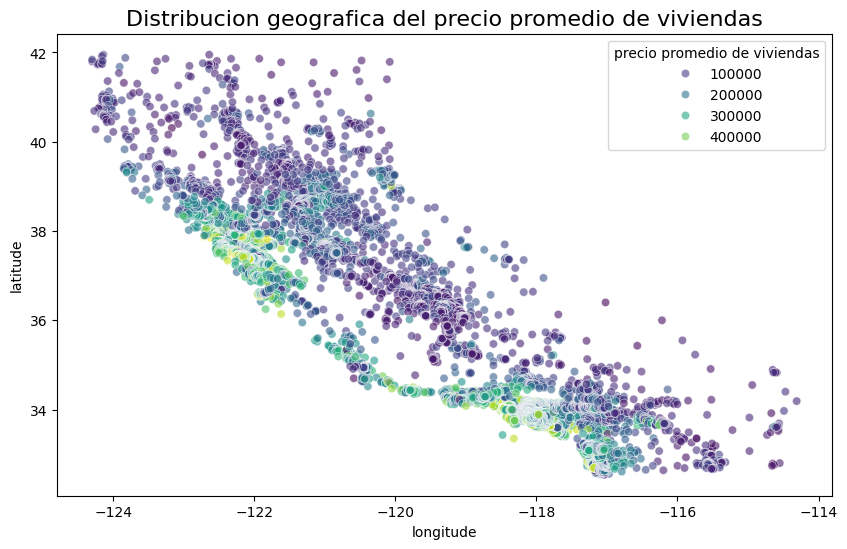

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='median_house_value', palette='viridis', alpha=0.6)
plt.legend(title='precio promedio de viviendas', loc='upper right')
plt.title('Distribucion geografica del precio promedio de viviendas', fontsize=16)
plt.show()

MATRIZ DE CORRELACIÓN
                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069120 -0.066484           -0.319026     0.927058   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069120    0.099773    0.055310      -0.015176   
latitude                 -0.066484   -0.108785   -0.071035     

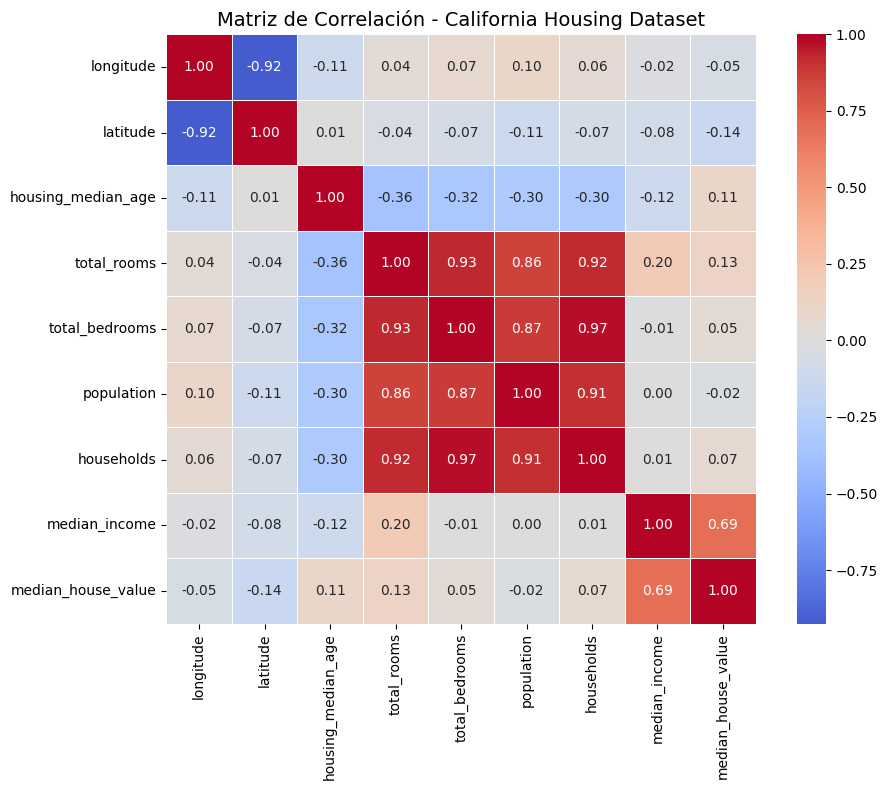

In [31]:
# MATRIZ DE CORRELACIÓN
# La correlación nos muestra cómo se relacionan las variables entre sí
# Valores cercanos a 1: correlación positiva fuerte
# Valores cercanos a -1: correlación negativa fuerte
# Valores cercanos a 0: poca o ninguna correlación

print("="*50)
print("MATRIZ DE CORRELACIÓN")
print("="*50)

# Calculamos la matriz de correlación solo para variables numéricas
correlacion = df.corr(numeric_only=True)

# Mostramos la matriz de correlación
print(correlacion)

# Visualizamos la matriz de correlación con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlación - California Housing Dataset', fontsize=14)
plt.tight_layout()
plt.show()

# INGENIERIA DE CARACTERISTICAS

In [32]:
LA, SF = (34.0522, -118.2437), (37.7749, -122.4194)

# creacion de variables geograficas (proximidad a centros economicos)
df_clean['dist_to_LA'] = np.sqrt((df_clean['latitude'] - LA[0])**2 + (df_clean['longitude'] - LA[1])**2)
df_clean['dist_to_SF'] = np.sqrt((df_clean['latitude'] - SF[0])**2 + (df_clean['longitude'] - SF[1])**2 )

#ratios
df_clean['bedrooms_per_room'] = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['pop_per_housegold'] = df_clean['population'] / df_clean['households']

#encoding de variables categoricas
df_clean = pd.get_dummies(df_clean, columns=['ocean_proximity'], drop_first=True)

# ANALISIS DE CORRELACION DE LAS NUEVAS VARIABLES

In [33]:
corr_matriz = df_clean.corr()
print("\nCorrelacion respecto al precio promedio de viviendas:")
display(corr_matriz['median_house_value'].sort_values(ascending=False))


Correlacion respecto al precio promedio de viviendas:


median_house_value            1.000000
median_income                 0.664341
total_rooms                   0.153769
ocean_proximity_NEAR OCEAN    0.147346
ocean_proximity_NEAR BAY      0.111688
households                    0.100436
total_bedrooms                0.079249
population                    0.022399
ocean_proximity_ISLAND        0.019534
housing_median_age            0.014207
dist_to_SF                   -0.015476
pop_per_housegold            -0.020200
longitude                    -0.022912
dist_to_LA                   -0.143450
latitude                     -0.171567
bedrooms_per_room            -0.227051
ocean_proximity_INLAND       -0.501263
Name: median_house_value, dtype: float64

# PREPARACION PARA LOS DATOS DEL MODELADO

In [34]:
# definir las variables predictorias y variables objetivo
x = df_clean.drop('median_house_value', axis=1)
y = df_clean['median_house_value']

#dividir el dataset en conjunto de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#escalar las caracteristicas
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [35]:
print(x)
print(y)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
8        -122.26     37.84                42.0       2555.0           665.0   
15       -122.26     37.85                50.0       1120.0           283.0   
18       -122.26     37.84                50.0       2239.0           455.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  dist_

# Modelado y Entrenamiento

In [37]:
# instanciar y entrenar el modelo de regresion lineal
linear_model=LinearRegression()
ridge_model = Ridge(alpha=10.0, random_state=42) # alpha es la fuerza de regularización
lasso_model = Lasso(alpha=50, random_state=42, max_iter=10000) 

#Entrenamos los modelos de aprendizaje
linear_model.fit(x_train_scaled, y_train)
ridge_model.fit(x_train_scaled, y_train)
lasso_model.fit(x_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",50
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


# Regresión lineal Standard

In [38]:
# Predicciones entrenamiento
y_train_pred_linear = linear_model.predict(x_train_scaled)

# Predicciones prueba
y_test_pred_linear = linear_model.predict(x_test_scaled)

# Cálculo de RMSE. Formula: RMSE: sqrt(mean((y_true - y_pred)^2)) 
rmse_train_linear = np.sqrt(np.mean((y_train - y_train_pred_linear) ** 2))
rmse_test_linear = np.sqrt(np.mean((y_test - y_test_pred_linear) ** 2))

#Calculo de MAE
mae_train_linear = np.mean(np.abs(y_train - y_train_pred_linear))
mae_test_linear = np.mean(np.abs(y_test - y_test_pred_linear))

#Mosttramos los resultados
print(f"Linear - RMSE Train: {rmse_train_linear:.2f}")
print(f"Linear - RMSE Test: {rmse_test_linear:.2f}")

print(f"Linear - MAE Train: {mae_train_linear:.2f}")
print(f"Linear - MAE Test: {mae_test_linear:.2f}")

#Importancia de variables
coef_linear = pd.DataFrame({'Característica': x.columns, 'Importancia': linear_model.coef_.round(3)})

coef_linear = coef_linear.sort_values(by='Importancia', key=abs, ascending=False)

display(coef_linear.head(10))

Linear - RMSE Train: 57330.01
Linear - RMSE Test: 57261.37
Linear - MAE Train: 41955.67
Linear - MAE Test: 42267.33


,Característica,Importancia
7,median_income,61997.456
5,population,-38464.037
6,households,29993.851
0,longitude,-26311.551
8,dist_to_LA,-23266.464
12,ocean_proximity_INLAND,-21393.725
1,latitude,-17693.367
9,dist_to_SF,-15731.574
10,bedrooms_per_room,11404.580
3,total_rooms,7104.186


# Modelo Ridge

In [40]:
# Predicciones
y_train_pred_ridge = ridge_model.predict(x_train_scaled)
y_test_pred_ridge = ridge_model.predict(x_test_scaled)

# Cálculo de RMSE. Formula: RMSE: sqrt(mean((y_true - y_pred)^2)) 
rmse_train_ridge = np.sqrt(np.mean((y_train - y_train_pred_ridge) ** 2))
rmse_test_ridge = np.sqrt(np.mean((y_test - y_test_pred_ridge) ** 2))

print(f"Ridge - RMSE Train: {rmse_train_ridge:.2f}")
print(f"Ridge - RMSE Test: {rmse_test_ridge:.2f}")

mae_train_ridge=np.mean(np.abs(y_train - y_train_pred_ridge))
mae_test_ridge=np.mean(np.abs(y_test - y_test_pred_ridge))

print(f"MAE Train: {mae_train_ridge:.2f}")
print(f"MAE Test: {mae_test_ridge:.2f}")

# Ver qué variables tienen coeficientes más grandes en el modelo Ridge
coeficientes = pd.DataFrame({ 'Característica': x.columns,'Importancia': ridge_model.coef_.round(3)}).sort_values(by='Importancia', key=abs, ascending=False)

print("\nImportancia de las características según el modelo Ridge:")
display(coeficientes.head(10))

Ridge - RMSE Train: 57330.29
Ridge - RMSE Test: 57255.13
MAE Train: 41958.59
MAE Test: 42264.60

Importancia de las características según el modelo Ridge:


,Característica,Importancia
7,median_income,61934.472
5,population,-38153.471
6,households,29423.475
0,longitude,-25702.655
8,dist_to_LA,-23197.983
12,ocean_proximity_INLAND,-21555.084
1,latitude,-17313.545
9,dist_to_SF,-15949.976
10,bedrooms_per_room,11325.072
3,total_rooms,6999.325


# Modelo LAsso (Regularización L1)

In [41]:
y_train_pred_lasso = lasso_model.predict(x_train_scaled)
y_test_pred_lasso = lasso_model.predict(x_test_scaled)

rmse_train_lasso = np.sqrt(np.mean((y_train - y_train_pred_lasso) ** 2))
rmse_test_lasso = np.sqrt(np.mean((y_test - y_test_pred_lasso) ** 2))

print(f"Lasso - RMSE Train: {rmse_train_lasso:.2f}")
print(f"Lasso - RMSE Test: {rmse_test_lasso:.2f}")

mae_train_lasso=np.mean(np.abs(y_train - y_train_pred_lasso))
mae_test_lasso=np.mean(np.abs(y_test - y_test_pred_lasso))

print(f"MAE Train: {mae_train_lasso:.2f}")
print(f"MAE Test: {mae_test_lasso:.2f}")

# Ver qué variables tienen coeficientes más grandes en el modelo Lasso
coeficientes_lasso = pd.DataFrame({
    'Característica': x.columns,
    'Importancia': lasso_model.coef_.round(3)
}).sort_values(by='Importancia', key=abs, ascending=False)

print("\nImportancia de las características según el modelo Lasso:")
display(coeficientes_lasso.head())

# Ver si lasso ha eliminado alguna variable (coeficiente exactamente 0)
variables_eliminadas = coeficientes_lasso[coeficientes_lasso['Importancia'] == 0]['Característica'].tolist()
print(f"\nVariables eliminadas por Lasso (coeficiente 0): {variables_eliminadas}")

Lasso - RMSE Train: 57331.80
Lasso - RMSE Test: 57253.64
MAE Train: 41953.47
MAE Test: 42260.12

Importancia de las características según el modelo Lasso:


,Característica,Importancia
7,median_income,61978.503
5,population,-37742.180
6,households,29465.904
0,longitude,-24923.557
8,dist_to_LA,-23182.754



Variables eliminadas por Lasso (coeficiente 0): []


# Graficas Valores Reales vs Predichos

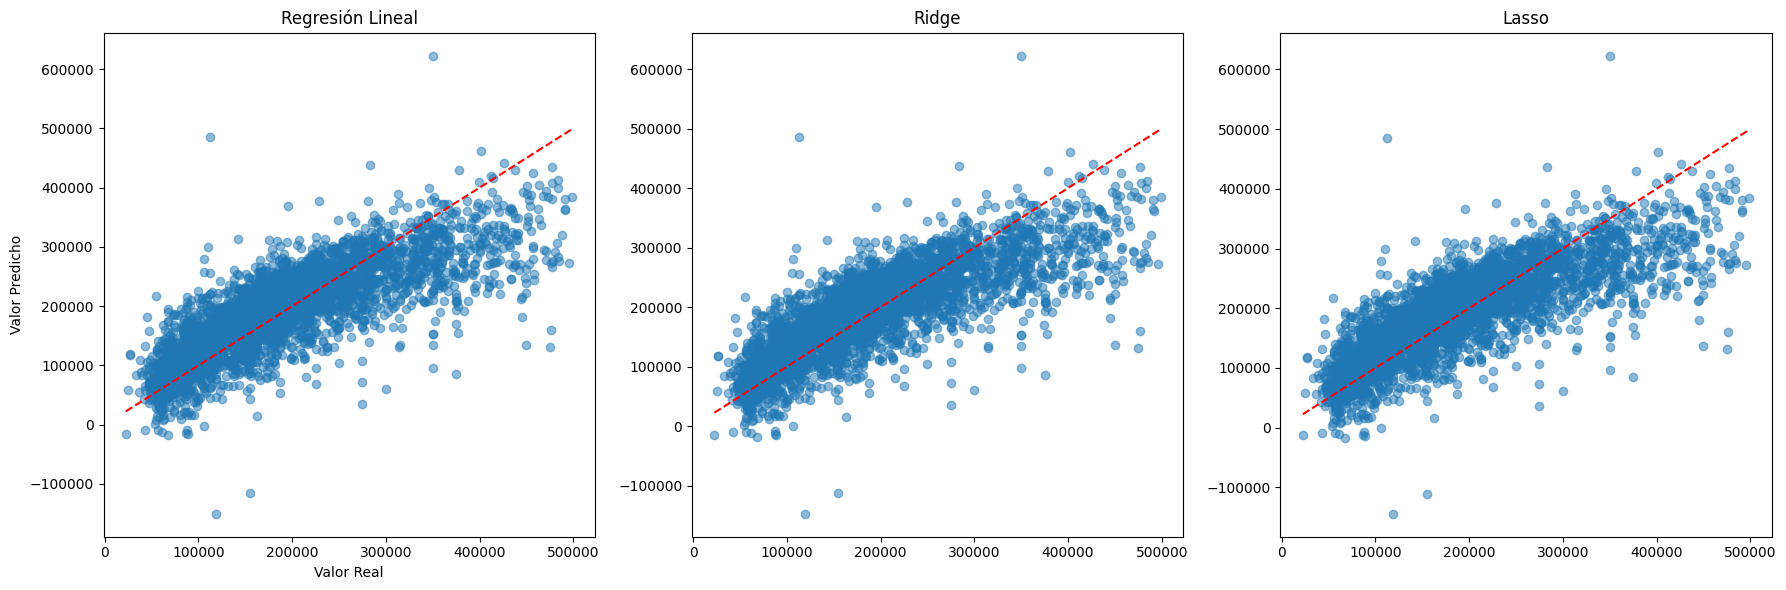

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(18,6))
#Linear
ax[0].scatter(y_test, y_test_pred_linear, alpha=0.5)
ax[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[0].set_title("Regresión Lineal")
ax[0].set_xlabel("Valor Real")
ax[0].set_ylabel("Valor Predicho")

#Ridge
ax[1].scatter(y_test, y_test_pred_ridge, alpha=0.5)
ax[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[1].set_title("Ridge")

# Lasso
ax[2].scatter(y_test, y_test_pred_lasso, alpha=0.5)
ax[2].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[2].set_title("Lasso")

plt.tight_layout()
plt.show()

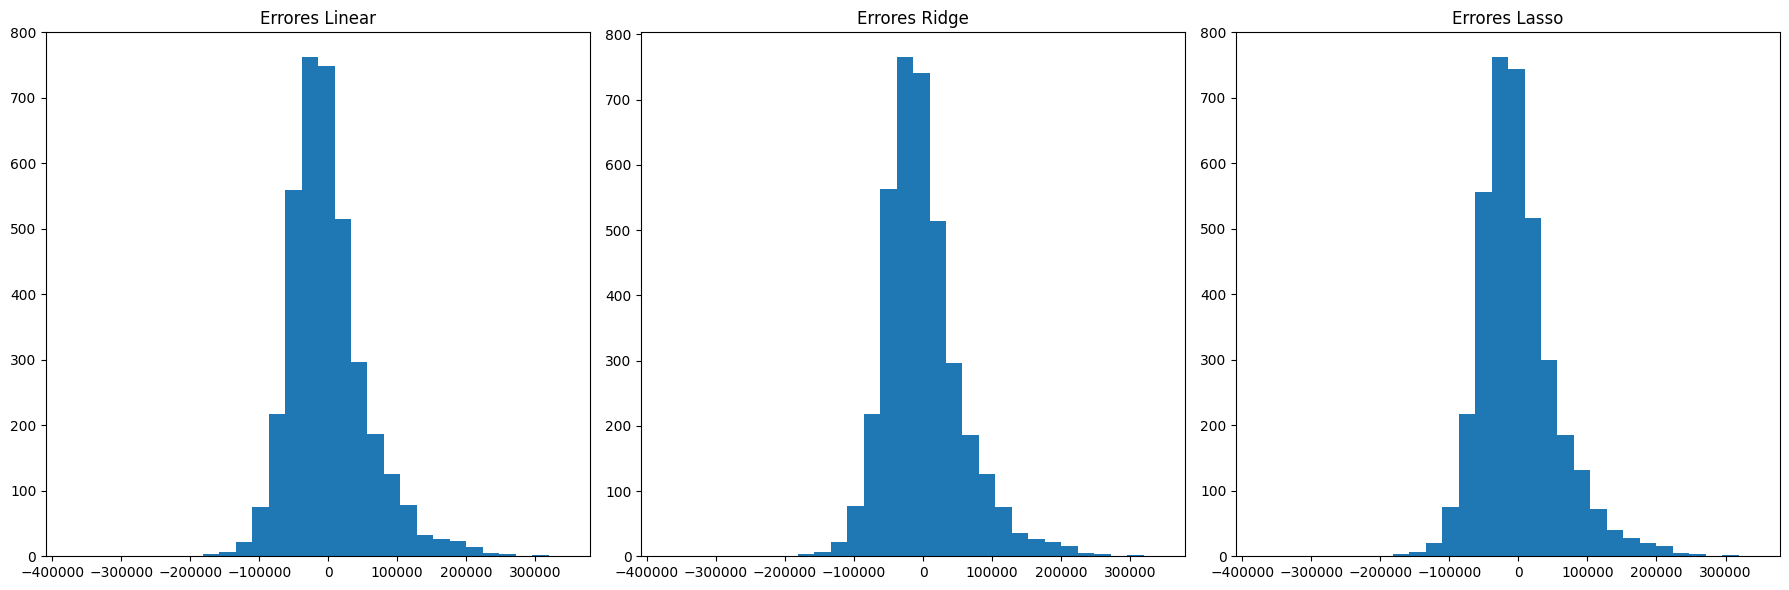

In [43]:
#Histogrma de error
fig, ax = plt.subplots(1,3, figsize=(18,6))

# Linear
ax[0].hist(
    y_test - y_test_pred_linear,
    bins=30
)
ax[0].set_title("Errores Linear")

# Ridge
ax[1].hist(
    y_test - y_test_pred_ridge,
    bins=30
)
ax[1].set_title("Errores Ridge")

# Lasso
ax[2].hist(
    y_test - y_test_pred_lasso,
    bins=30
)
ax[2].set_title("Errores Lasso")

plt.tight_layout()
plt.show()

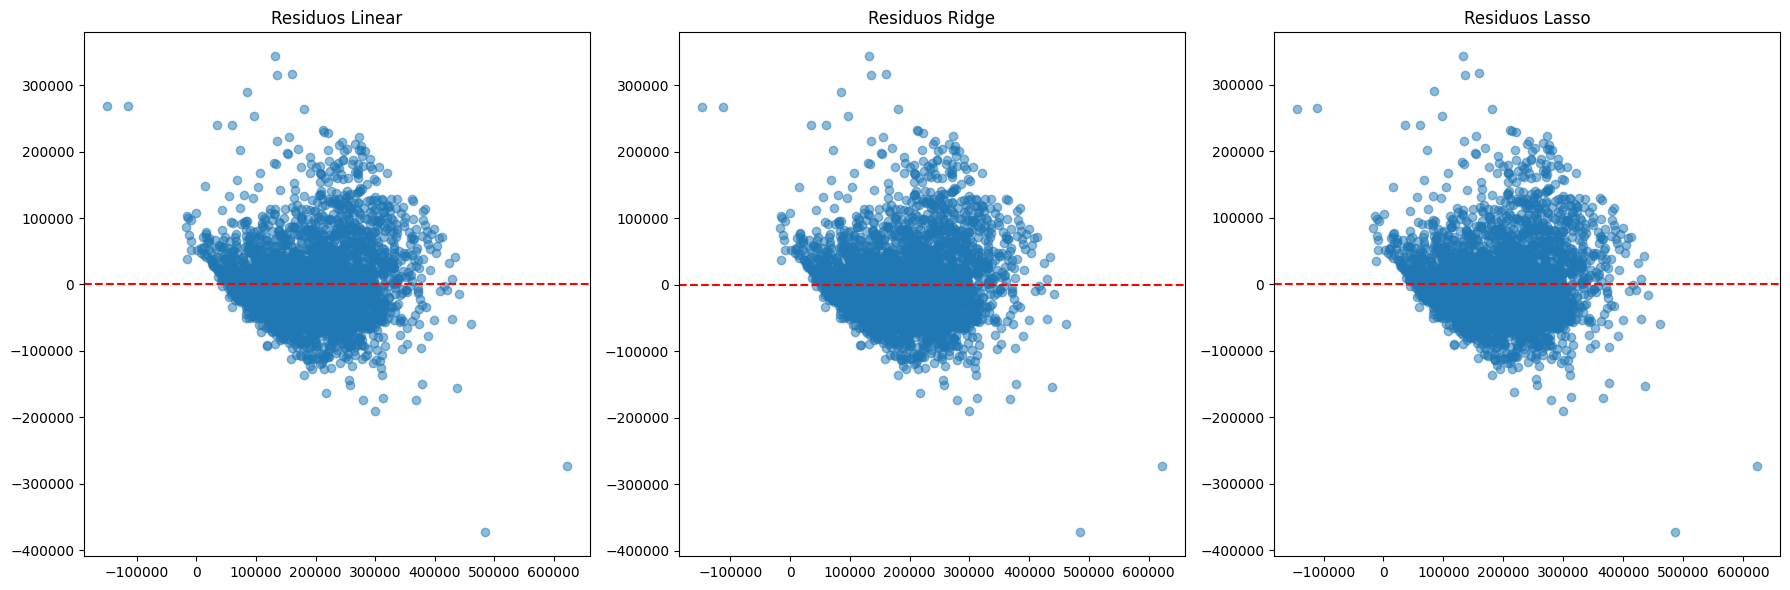

In [44]:
fig, ax = plt.subplots(1,3, figsize=(18,6))

# Linear
res_linear = y_test - y_test_pred_linear

ax[0].scatter(
    y_test_pred_linear,
    res_linear,
    alpha=0.5
)

ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title("Residuos Linear")

# Ridge
res_ridge = y_test - y_test_pred_ridge

ax[1].scatter(
    y_test_pred_ridge,
    res_ridge,
    alpha=0.5
)

ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title("Residuos Ridge")

# Lasso
res_lasso = y_test - y_test_pred_lasso

ax[2].scatter(
    y_test_pred_lasso,
    res_lasso,
    alpha=0.5
)

ax[2].axhline(0, color='red', linestyle='--')
ax[2].set_title("Residuos Lasso")

plt.tight_layout()
plt.show()

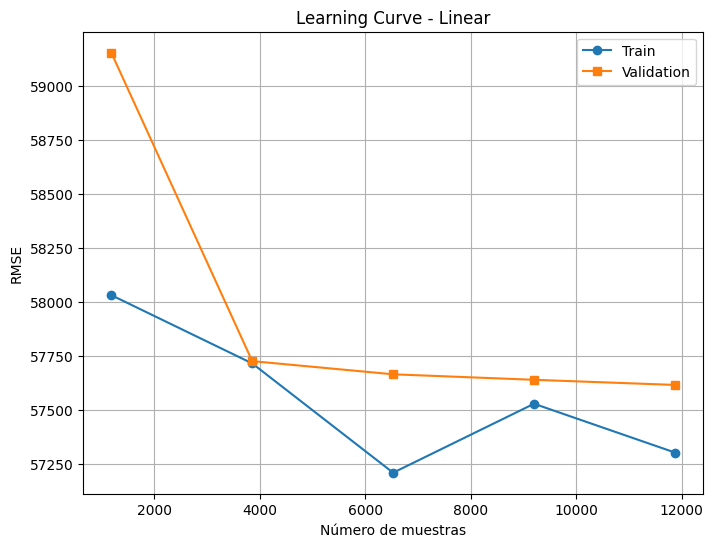

In [46]:
#Curva de aprendizaje regrsión standar
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    linear_model,
    x_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Linear")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

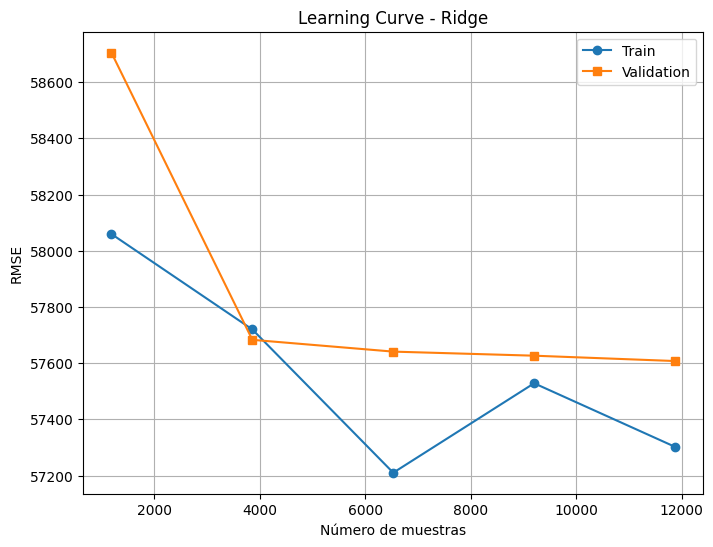

In [47]:
#Curva de aprendizaje regrsión ridge

train_sizes, train_scores, test_scores = learning_curve(
    ridge_model,
    x_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Ridge")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

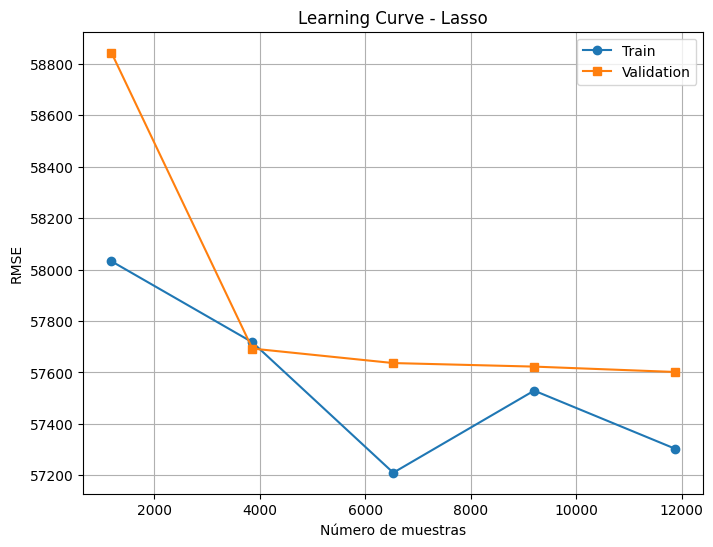

In [48]:
#Curva de aprendizaje regrsión lasso
train_sizes, train_scores, test_scores = learning_curve(
    lasso_model,
    x_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Lasso")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

# Conclusión
* **Diagnóstico de Sobreajuste (Overfitting):** El Error Cuadrático Medio (RMSE) en los conjuntos de entrenamiento y prueba es sumamente similar para ambos modelos. Esto indica que la regularización aplicada es efectiva y que los modelos generalizan correctamente sin memorizar el ruido de entrenamiento.
* **Comportamiento del Modelo Lasso (L1):** A pesar del uso de regularización L1 (con α=50), el modelo Lasso no ha reducido a cero ningún coeficiente. Esto sugiere que, a este nivel de penalización, todas las características de entrada conservan relevancia predictiva y no hay redundancia crítica.
* **Comparativa de Modelos:** El modelo Ridge (L2) presenta un rendimiento marginalmente superior en el conjunto de prueba, lo que indica que una penalización suave distribuida sobre todas las variables (L2) es más adecuada para este conjunto de datos que la selección estricta de variables (L1).

# Comparación de los modelos

In [49]:
comparacion = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso'],
    'RMSE Train': [
        rmse_train_linear,
        rmse_train_ridge,
        rmse_train_lasso
    ],
    'RMSE Test': [
        rmse_test_linear,
        rmse_test_ridge,
        rmse_test_lasso
    ],
    'MAE Train': [
        mae_train_linear,
        mae_train_ridge,
        mae_train_lasso
    ],
    'MAE Test': [
        mae_test_linear,
        mae_test_ridge,
        mae_test_lasso
    ]
})

comparacion

,Modelo,RMSE Train,RMSE Test,MAE Train,MAE Test
0,Linear,57330.006736,57261.373128,41955.672722,42267.328597
1,Ridge,57330.293705,57255.128087,41958.589108,42264.599484
2,Lasso,57331.799208,57253.640824,41953.469481,42260.119648


### Deber para terminar el pippeline guardar y cargar el modelo lasso e ingresar nuevos valores por teclado y predecir el precio de una vivienda.

In [51]:
# importacion de las librerias joblib y pipeline
import joblib
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline

In [52]:
# Crear un pipeline que incluye escalado y modelo Lasso
pipeline_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=50, random_state=42, max_iter=10000))
])

# Entrenar el pipeline con los datos originales (sin escalar previamente)
pipeline_lasso.fit(x_train, y_train)

print("✅ Pipeline entrenado exitosamente!")

# Evaluar el pipeline
y_pred_pipeline = pipeline_lasso.predict(x_test)
rmse_pipeline = np.sqrt(np.mean((y_test - y_pred_pipeline) ** 2))
print(f"📊 RMSE del Pipeline Lasso: ${rmse_pipeline:,.2f}")

# GUARDAR el pipeline completo (modelo + scaler + todo)
joblib.dump(pipeline_lasso, 'pipeline_lasso_california.pkl')
print("\n💾 Pipeline guardado como 'pipeline_lasso_california.pkl'")

# También guardar por separado (por si acaso)
joblib.dump(lasso_model, 'modelo_lasso.pkl')
joblib.dump(scaler, 'scaler_lasso.pkl')
print("💾 Modelo Lasso guardado como 'modelo_lasso.pkl'")
print("💾 Scaler guardado como 'scaler_lasso.pkl'")

# Guardar los nombres de las columnas (importante para predicciones)
joblib.dump(list(x.columns), 'columnas_modelo.pkl')
print("💾 Nombres de columnas guardados")

✅ Pipeline entrenado exitosamente!
📊 RMSE del Pipeline Lasso: $57,253.64

💾 Pipeline guardado como 'pipeline_lasso_california.pkl'
💾 Modelo Lasso guardado como 'modelo_lasso.pkl'
💾 Scaler guardado como 'scaler_lasso.pkl'
💾 Nombres de columnas guardados


In [56]:
def cargar_y_predecir():
    """Carga el pipeline y predice con valores ingresados por teclado"""
    
    print("\n" + "="*60)
    print("🏠 SISTEMA DE PREDICCIÓN - PRECIOS VIVIENDAS CALIFORNIA")
    print("="*60)
    
    # Cargar el pipeline guardado (contiene el escalador y el modelo Lasso)
    pipeline_cargado = joblib.load('pipeline_lasso_california.pkl')
    
    # Cargar nombres de columnas (necesario para crear el DataFrame en el orden correcto)
    columnas = joblib.load('columnas_modelo.pkl')
    
    print("\n📋 Características necesarias para la predicción:")
    print("-"*50)
    for i, col in enumerate(columnas, 1):
        print(f"{i:2}. {col}")
    
    print("\n" + "="*60)
    print("📝 INGRESO DE DATOS DE LA VIVIENDA")
    print("="*60)
    
    # Diccionario para almacenar valores ingresados
    valores = {}
    
    # Descripción de cada variable para facilitar el ingreso
    descripciones = {
        'MedInc': 'Ingreso medio del bloque (miles de USD)',
        'HouseAge': 'Edad media de la vivienda (años)',
        'AveRooms': 'Promedio de habitaciones por vivienda',
        'AveBedrms': 'Promedio de dormitorios por vivienda',
        'Population': 'Población del bloque',
        'AveOccup': 'Promedio de ocupación por vivienda',
        'Latitude': 'Latitud',
        'Longitude': 'Longitud',
        'total_bedrooms': 'Total de dormitorios en el bloque',
        'total_rooms': 'Total de habitaciones en el bloque',
        'households': 'Total de hogares en el bloque',
        'dist_to_LA': 'Distancia a Los Ángeles (grados)',
        'dist_to_SF': 'Distancia a San Francisco (grados)',
        'bedrooms_per_room': 'Proporción dormitorios/habitaciones',
        'pop_per_housegold': 'Personas por hogar',
        'ocean_proximity_1H_OCEAN': '¿1H OCEAN? (1=Sí, 0=No)',
        'ocean_proximity_INLAND': '¿INLAND? (1=Sí, 0=No)',
        'ocean_proximity_NEAR_BAY': '¿NEAR BAY? (1=Sí, 0=No)',
        'ocean_proximity_NEAR_OCEAN': '¿NEAR OCEAN? (1=Sí, 0=No)'
    }
    
    # Ingresar valores por teclado (bucle con validación)
    for col in columnas:
        while True:
            try:
                desc = descripciones.get(col, col)
                if col.startswith('ocean_proximity'):
                    print(f"\n{col}:")
                    print(f"   {desc}")
                    valor = float(input(f"   Valor (0 o 1): "))
                    if valor not in [0, 1]:
                        print("   ⚠️ Debe ser 0 o 1")
                        continue
                else:
                    valor = float(input(f"{col} - {desc}: "))
                valores[col] = valor
                break
            except ValueError:
                print("   ⚠️ Error: Ingresa un número válido")
    
    # Crear DataFrame con los valores ingresados en el orden correcto
    nuevo_dato = pd.DataFrame([valores])
    
    print("\n" + "="*60)
    print("📊 DATOS INGRESADOS:")
    print("="*60)
    for col in columnas:
        print(f"   {col}: {valores[col]}")
    
    # Realizar la predicción
    prediccion = pipeline_cargado.predict(nuevo_dato)[0]
    
    print("\n" + "="*60)
    print("🏠 RESULTADO DE LA PREDICCIÓN:")
    print("="*60)
    print(f"   💰 Precio estimado: ${prediccion:,.2f} USD")
    print(f"   📊 En cientos de miles: {prediccion/100000:.2f}")
    print("="*60)
    
    return prediccion

In [55]:
# ejecucion de pruebas

if __name__ == "__main__":
    print("\n🔧 VERIFICANDO ARCHIVOS GUARDADOS...")
    
    # Verificar si ya existe el pipeline
    import os
    if not os.path.exists('pipeline_lasso_california.pkl'):
        print("⚠️ No se encontró el pipeline. Ejecutando PARTE 1 para crearlo...")
        # Aquí iría el código de la PARTE 1 (ya lo tienes arriba)
    else:
        print("✅ Pipeline encontrado!")
    
    # Predicción completa con todas las variables
    print("\n" + "🔹"*30)
    print("OPCIÓN 1: PREDICCIÓN COMPLETA")
    print("🔹"*30)
    resultado = cargar_y_predecir()


🔧 VERIFICANDO ARCHIVOS GUARDADOS...
✅ Pipeline encontrado!

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
OPCIÓN 1: PREDICCIÓN COMPLETA
🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

🏠 SISTEMA DE PREDICCIÓN - PRECIOS VIVIENDAS CALIFORNIA

📋 Características necesarias para la predicción:
--------------------------------------------------
 1. longitude
 2. latitude
 3. housing_median_age
 4. total_rooms
 5. total_bedrooms
 6. population
 7. households
 8. median_income
 9. dist_to_LA
10. dist_to_SF
11. bedrooms_per_room
12. pop_per_housegold
13. ocean_proximity_INLAND
14. ocean_proximity_ISLAND
15. ocean_proximity_NEAR BAY
16. ocean_proximity_NEAR OCEAN

📝 INGRESO DE DATOS DE LA VIVIENDA


longitude - longitude:  -122.23
latitude - latitude:  37.88
housing_median_age - housing_median_age:  41
total_rooms - Total de habitaciones en el bloque:  2650
total_bedrooms - Total de dormitorios en el bloque:  520
population - population:  1450
households - Total de hogares en el bloque:  480
median_income - median_income:  8.3
dist_to_LA - Distancia a Los Ángeles (grados):  5.8
dist_to_SF - Distancia a San Francisco (grados):  0.3
bedrooms_per_room - Proporción dormitorios/habitaciones:  0.196
pop_per_housegold - Personas por hogar:  3.02



ocean_proximity_INLAND:
   ¿INLAND? (1=Sí, 0=No)


   Valor (0 o 1):  0



ocean_proximity_ISLAND:
   ocean_proximity_ISLAND


   Valor (0 o 1):  0



ocean_proximity_NEAR BAY:
   ocean_proximity_NEAR BAY


   Valor (0 o 1):  0



ocean_proximity_NEAR OCEAN:
   ocean_proximity_NEAR OCEAN


   Valor (0 o 1):  1



📊 DATOS INGRESADOS:
   longitude: -122.23
   latitude: 37.88
   housing_median_age: 41.0
   total_rooms: 2650.0
   total_bedrooms: 520.0
   population: 1450.0
   households: 480.0
   median_income: 8.3
   dist_to_LA: 5.8
   dist_to_SF: 0.3
   bedrooms_per_room: 0.196
   pop_per_housegold: 3.02
   ocean_proximity_INLAND: 0.0
   ocean_proximity_ISLAND: 0.0
   ocean_proximity_NEAR BAY: 0.0
   ocean_proximity_NEAR OCEAN: 1.0

🏠 RESULTADO DE LA PREDICCIÓN:
   💰 Precio estimado: $415,714.79 USD
   📊 En cientos de miles: 4.16
